METRICAS MAE E MSE

In [63]:
import pandas as pd
import numpy as np
from IPython.display import display, Image
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [64]:
df = pd.read_csv('moradia.csv', delimiter = ',')
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [65]:
df = df.rename(columns={
    'longitude': 'longitude',
    'latitude': 'latitude',
    'housing_median_age': 'idade_mediana_casas',
    'total_rooms': 'total_comodos',
    'total_bedrooms': 'total_quartos',
    'population': 'populacao',
    'households': 'domicilios',
    'median_income': 'renda_mediana',
    'median_house_value': 'valor_mediano_casa',
    'ocean_proximity': 'proximidade_oceano'
})
df.head()

,longitude,latitude,idade_mediana_casas,total_comodos,total_quartos,populacao,domicilios,renda_mediana,valor_mediano_casa,proximidade_oceano
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


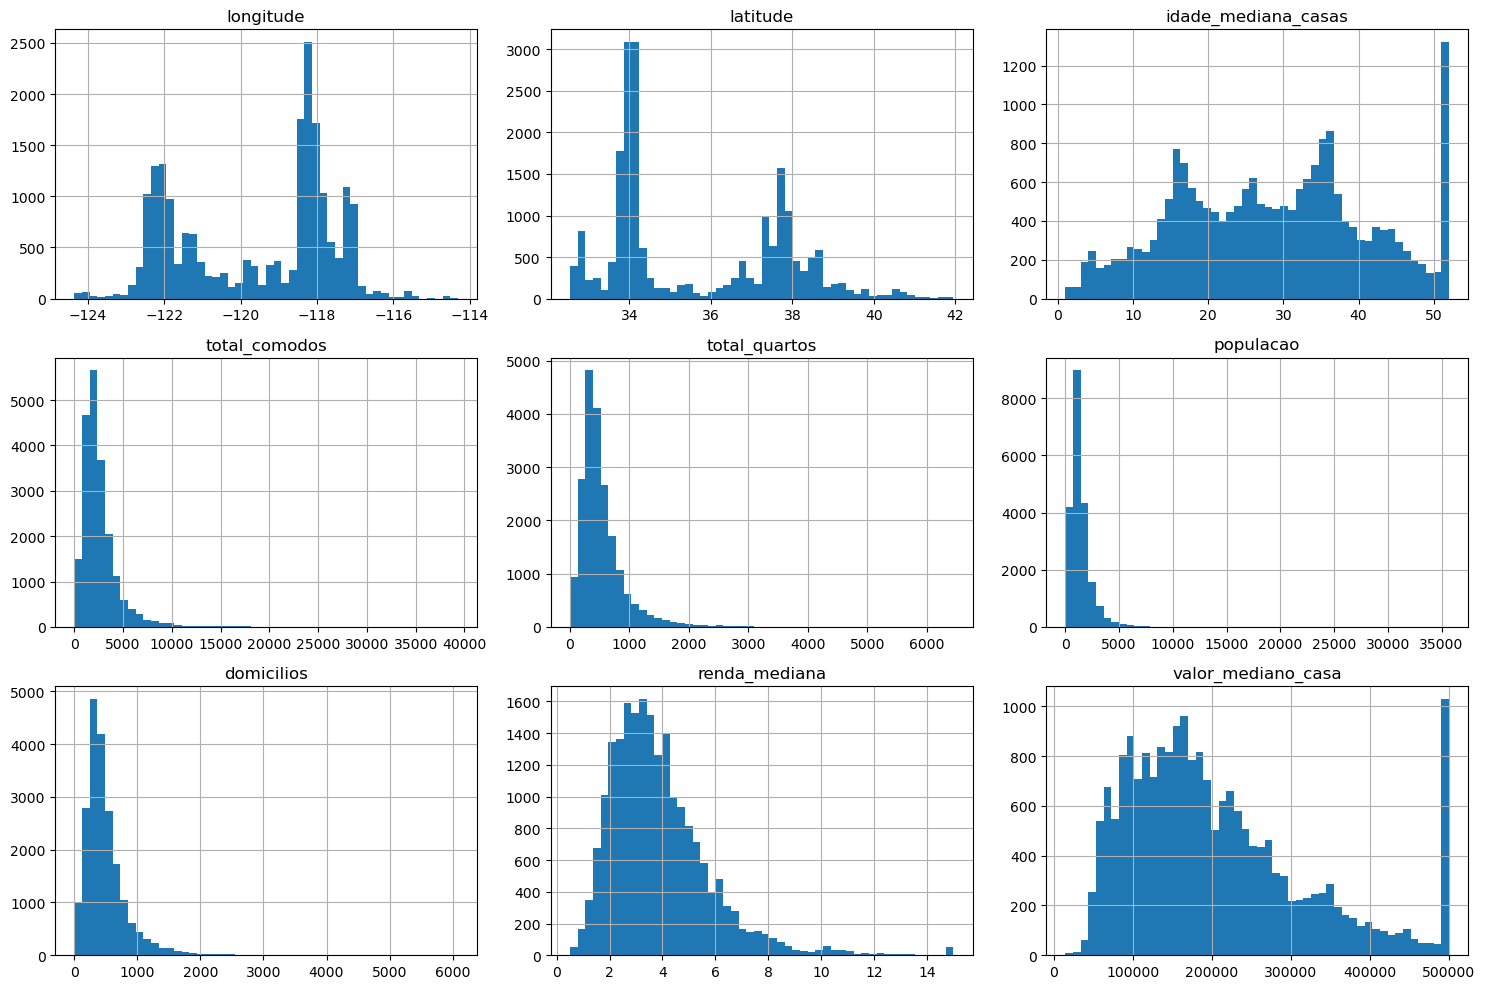

In [66]:
df.hist(bins=50, figsize=(15,10))
plt.tight_layout()
plt.show()

In [67]:
#Verificando os tipos de dados e informações necessárias
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   longitude            20640 non-null  float64
 1   latitude             20640 non-null  float64
 2   idade_mediana_casas  20640 non-null  float64
 3   total_comodos        20640 non-null  float64
 4   total_quartos        20433 non-null  float64
 5   populacao            20640 non-null  float64
 6   domicilios           20640 non-null  float64
 7   renda_mediana        20640 non-null  float64
 8   valor_mediano_casa   20640 non-null  float64
 9   proximidade_oceano   20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [68]:
#contando os valores nulos
df.isnull().sum()


longitude                0
latitude                 0
idade_mediana_casas      0
total_comodos            0
total_quartos          207
populacao                0
domicilios               0
renda_mediana            0
valor_mediano_casa       0
proximidade_oceano       0
dtype: int64

In [69]:
#porcentagem dos valores nulos
df.isnull().mean() * 100

longitude              0.000000
latitude               0.000000
idade_mediana_casas    0.000000
total_comodos          0.000000
total_quartos          1.002907
populacao              0.000000
domicilios             0.000000
renda_mediana          0.000000
valor_mediano_casa     0.000000
proximidade_oceano     0.000000
dtype: float64

In [70]:
#ver as linhas que tên valores nulos
df[df.isnull().any(axis=1)]

,longitude,latitude,idade_mediana_casas,total_comodos,total_quartos,populacao,domicilios,renda_mediana,valor_mediano_casa,proximidade_oceano
290,-122.16,37.77,47.0,1256.0,NaN,570.0,218.0,4.3750,161900.0,NEAR BAY
341,-122.17,37.75,38.0,992.0,NaN,732.0,259.0,1.6196,85100.0,NEAR BAY
538,-122.28,37.78,29.0,5154.0,NaN,3741.0,1273.0,2.5762,173400.0,NEAR BAY
563,-122.24,37.75,45.0,891.0,NaN,384.0,146.0,4.9489,247100.0,NEAR BAY
696,-122.10,37.69,41.0,746.0,NaN,387.0,161.0,3.9063,178400.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20267,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20268,-119.18,34.19,19.0,2393.0,NaN,1938.0,762.0,1.6953,167400.0,NEAR OCEAN
20372,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN
20460,-118.75,34.29,17.0,5512.0,NaN,2734.0,814.0,6.6073,258100.0,<1H OCEAN


In [71]:
#deletando dados nulos
dados = df.dropna()

In [72]:
dados = pd.get_dummies(dados, columns=['proximidade_oceano'])
dados.head()
dados.to_csv('moradia_tratada.csv', index=False)


In [73]:
y = dados['valor_mediano_casa']
x = dados.drop(columns='valor_mediano_casa')
x.shape
y.shape

(20433,)

In [74]:
from sklearn.model_selection import train_test_split

x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size=0.2, random_state=42)
x_treino.shape, x_teste.shape


((16346, 13), (4087, 13))

In [78]:
from sklearn.linear_model import LinearRegression
modelo = LinearRegression()
modelo.fit(x_treino, y_treino)


LinearRegression()

In [79]:
previsoes = modelo.predict(x_teste)


In [82]:
mae = mean_absolute_error(y_teste, previsoes)
mse = mean_squared_error(y_teste, previsoes)
rmse = np.sqrt(mse)
print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)


MAE: 50413.433308100524
MSE: 4802173538.604143
RMSE: 69297.71669113019


In [83]:
x_treino.shape, x_teste.shape


((16346, 13), (4087, 13))